In [1]:
# Boilerplate for JupyterLite 
import install_keycap_designer
from keycap_designer.jupyter import *

Manuscript(profile=Profile('Junana'), specifier=Specifier('1u'), comment=Comment('Hello! This is comment.'))
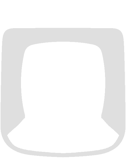

In [2]:
# Comment
Junana @ Specifier('1u') @ Comment('Hello! This is comment.')


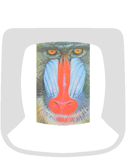
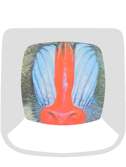
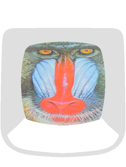
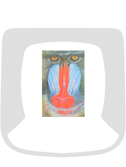

In [3]:
# Image fit
top_image1 = TopImage('portlait.jpg') @ Comment('Default (Aspect): Makes margin.')
top_image2 = TopImage('portlait.jpg', fit=Crop) @ Comment('Crop: No margin, crops image.')
top_image3 = TopImage('portlait.jpg', fit=Expand) @ Comment('Expand: Ignores aspect ratio and makes no margin.')
top_image4 = TopImage('portlait.jpg', fit=PixelWise) @ Comment('PixelWise: Reproduce each pixel.')
show_inline(Junana @ Specifier('1u') >> [top_image1, top_image2, top_image3, top_image4])


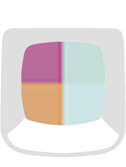
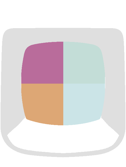

In [4]:
# Image interpolate
top_image1 = TopImage('wallpaper_pattern.png') @ Comment('Default (Cubic): Makes blur in small images.')
top_image2 = TopImage('wallpaper_pattern.png', interpolate=Nearest) @ Comment('Nearest: Keeps sharp edges of small images')
show_inline(Junana @ Specifier('1u') >> [top_image1, top_image2])


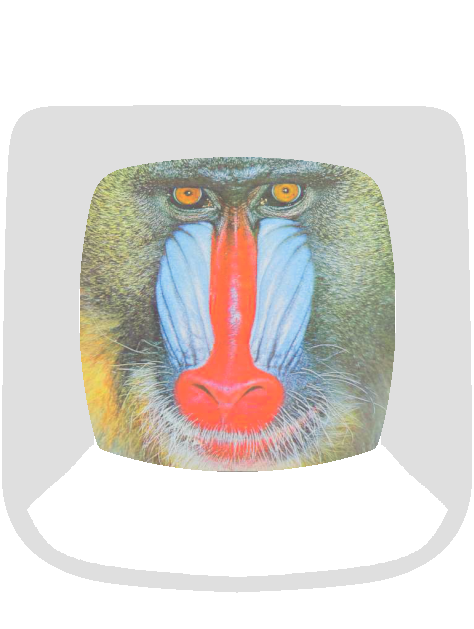
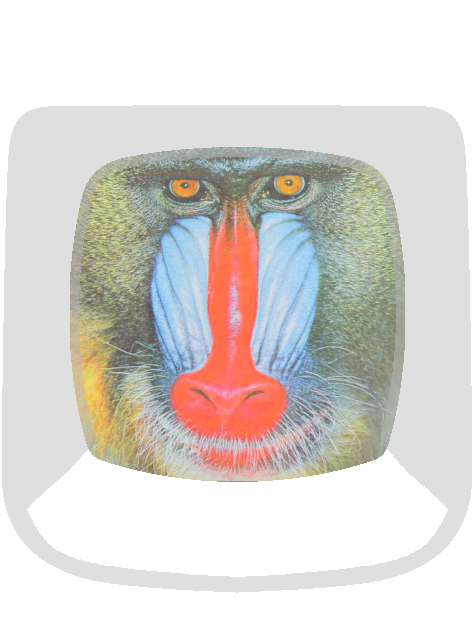

In [5]:
# Image trim
top_image1 = TopImage('mandrill.jpg') @ Comment('Default (TrimInner): Makes margin from the edges of the keycap.')
top_image2 = TopImage('mandrill.jpg', trim=TrimOuter) @ Comment('TrimOuter: Makes no margin.')
show_inline(Junana @ Specifier('1u') >> [top_image1, top_image2], dpi=720)


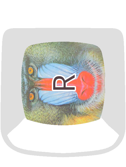
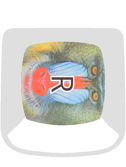
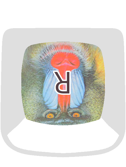
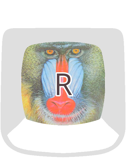

In [6]:
# Rotation
# You can rotate image and legends by `Rotate()`
s_center = Style(
    size=4.,
    x_loc=0.,
    y_loc=0.,
    font='OpenSans-VariableFont_wdth,wght.ttf',
    h_o=Center,
    align=Center,
    v_o=Center,
    color= sRGBColor('#000000'),
    side=TopSide
)
m = Junana @ Specifier('1u') @ Legend({s_center: 'R'}) @ TopImage('mandrill.jpg')
show_inline(m >> [Rotation(r) for r in [RotationAngle.CW, RotationAngle.CCW, RotationAngle.Flip, RotationAngle.Right]])

Manuscript(profile=Profile('Junana'), specifier=Specifier('1u'), legend=Legend({Style(size=4.0, x_loc=0.0, y_loc=0.0, font='OpenSans-VariableFont_wdth,wght.ttf', h_o=Orientation.Center, v_o=Orientation.Center, align=Orientation.Center): 'R', Style(size=4.0, x_loc=2.0, y_loc=1.0, font='OpenSans-VariableFont_wdth,wght.ttf', h_o=Orientation.Center, v_o=Orientation.Center, align=Orientation.Center): 'S'}))
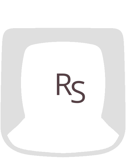

In [7]:
# Legend shift
s_center_shifted = s_center.shift(x=2., y=1.)
Junana @ Specifier('1u') @ Legend({s_center: 'R', s_center_shifted: 'S'})

In [8]:
# Variable font
# Check font's variation names first
from PIL import ImageFont
font = ImageFont.truetype('OpenSans-VariableFont_wdth,wght.ttf', 40)
font.get_variation_names()

[b'Light',
 b'Regular',
 b'SemiBold',
 b'Bold',
 b'ExtraBold',
 b'Condensed Light',
 b'Condensed Regular',
 b'Condensed SemiBold',
 b'Condensed Bold',
 b'Condensed ExtraBold']

Manuscript(profile=Profile('Junana'), specifier=Specifier('1u'), legend=Legend({Style(size=4.0, x_loc=0.0, y_loc=0.0, font='OpenSans-VariableFont_wdth,wght.ttf', h_o=Orientation.Center, v_o=Orientation.Center, align=Orientation.Center, variation_name='ExtraBold'): 'R', Style(size=4.0, x_loc=2.0, y_loc=1.0, font='OpenSans-VariableFont_wdth,wght.ttf', h_o=Orientation.Center, v_o=Orientation.Center, align=Orientation.Center): 'R'}))
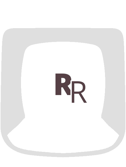

In [9]:
# Specify variation name
s_center_eb = s_center.mod(variation_name='ExtraBold')
Junana @ Specifier('1u') @ Legend({s_center_eb: 'R', s_center_shifted: 'R'})

In [10]:
# Check font's variation axes first
font.get_variation_axes()

[{'minimum': 300, 'default': 400, 'maximum': 800, 'name': b'Weight'},
 {'minimum': 75, 'default': 100, 'maximum': 100, 'name': b'Width'}]


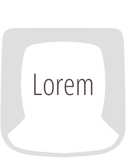
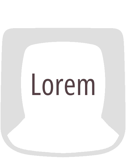
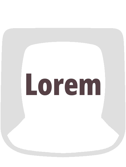

In [11]:
# Specify variation axes
s_center_axes = s_center.mod(variation_axes=(100.0, 62.0))
show_inline(Junana @ Specifier('1u') >> [Legend({s_center.mod(variation_axes=(we, 62.0)): 'Lorem'}) for we in [100., 400., 900]])

In [12]:
# Skip
# This feature is for making keycap set.
ms = [Comment('Col 0'), Comment('Skip 2') @ Skip(2), Comment('Col 3'), Comment('Col 4')]
ms

[Comment('Col 0'),
 Manuscript(comment=Comment('Skip 2'), skip=Skip(2)),
 Comment('Col 3'),
 Comment('Col 4')]

In [13]:
# operator `**` makes...
Col(0) ** ms
# 'Skip 2' is vanished and col is incremented from 0 to 3.

[Manuscript(col=Col(0), comment=Comment('Col 0')),
 Manuscript(col=Col(3), comment=Comment('Col 3')),
 Manuscript(col=Col(4), comment=Comment('Col 4'))]

In [14]:
# You can use Skip() with Row too.
cs = Row(0) ** [Comment('Row 0'), Skip(3), Comment('Row 4'), Comment('Row 5')]
cs

[Manuscript(row=Row(0), comment=Comment('Row 0')),
 Manuscript(row=Row(4), comment=Comment('Row 4')),
 Manuscript(row=Row(5), comment=Comment('Row 5'))]